# 任务二：构建结构化数据资产
1. 创建一份标准的 “K7直播间短视频分析表”。该表至少应包含：视频ID、分类标签（爆款/非爆款）、发布时间、核心绩效指标（如播放量、互动率、转化率、GMV等）、以及文本信息字段。
2. 确保主表结构清晰，便于后续进行分组统计与可视化分析。


## Yahui 产出说明

### 1) main_perf_merged_common.xlsx
- 内容：金运抖音每日绩效主表与k7素材共有字段（包含Kai构造的所有拓展字段），以及爆款/非爆款标签is_popular和数据来源source（dy/k7）。
- 作用：用于两批数据联动，分析核心绩效指标分布等。

### 2) main_perf_merged_full.xlsx
- 内容：金运抖音每日绩效主表与k7素材全字段，非共有指标空值填充，同样包含is_popular和数据来源source。
- 作用：能够直接在该表中查到所有指标，可按需选取该表和merged_common表。     

### 3) k7_main_perf.xlsx
- 内容：k7素材全部字段，包含清洗后的原始字段、拓展字段、视频文件match得到的爆款标签is_pop_match_mv以及根据绩效数据全部打标的爆款标签is_popular。
- 作用：根据k7数据进行分析，可以查看两种打标方式的分组差异。

### 4) dy_main_perf.xlsx
- 内容：金运抖音素材全部字段，包含清洗后的原始字段、拓展字段、以及根据绩效数据全部打标的爆款标签is_popular（该部分无爆款/非爆款视频文件提供）。
- 作用：根据dy数据进行分析，样本量更大、指标更全。

## 处理过程
- 把llm评分分别合并到对应的主表中，查看现有数据分布和质量，进一步清洗部分异常值和数据格式
- 根据核心绩效指标分布，构建is_popular字段，对爆款/非爆款素材打标
- 输出几版主表：  
  1、合并两批素材，仅保留共有指标和is_popular标签  
  2、合并两批素材，保留全部指标（非共有指标用空值填充）  
  3、k7直播间素材(近期)全指标  
  4、抖音数据（2023-03-28 到 2025-06-30）全指标


In [ ]:
#预览已有数据成果并进行描述性统计

import pandas as pd
import os

#预处理后数据 from Kai
dy_source_path_zb = os.path.join('../', 'Processed_Data', 'dy_daily_perf_with_mv_match.xlsx')              # 抖音数据主表
dy_source_path_llm = os.path.join('../', 'Processed_Data', 'dy_meaningful_titles_analysis_result.xlsx')    # 抖音数据LLM分析结果表
k7_source_path_zb = os.path.join('../', 'Processed_Data', 'k7_material_desc_with_mv_match.xlsx')           # K7素材数据主表
k7_source_path_llm = os.path.join('../', 'Processed_Data', 'k7_meaningful_titles_analysis_result.xlsx')    # K7素材数据LLM分析结果表

#读取为dataframe
dy_zb_df = pd.read_excel(dy_source_path_zb)
dy_llm_df = pd.read_excel(dy_source_path_llm)
k7_zb_df = pd.read_excel(k7_source_path_zb)
k7_llm_df = pd.read_excel(k7_source_path_llm)

#主要关注描述性统计，如需展示前10行可以取消注释
# # ===================== 展示前10行 =====================
# print("="*80)
# print("dy_zb 前10行")
# print("="*80)
# print(dy_zb_df.head(10).to_string(index=False))

# print("\n" + "="*80)
# print("dy_llm 前10行")
# print("="*80)
# print(dy_llm_df.head(10).to_string(index=False))

# print("\n" + "="*80)
# print("k7_zb 前10行")
# print("="*80)
# print(k7_zb_df.head(10).to_string(index=False))

# print("\n" + "="*80)
# print("k7_llm 前10行")
# print("="*80)
# print(k7_llm_df .head(10).to_string(index=False))

# ===================== 描述性统计 =====================
print("\n" + "="*80)
print("dy_zb 描述性统计")
print("="*80)
print(dy_zb_df.describe().transpose().to_string())

print("\n" + "="*80)
print("dy_llm 描述性统计")
print("="*80)
print(dy_llm_df.describe().transpose().to_string())

print("\n" + "="*80)
print("k7_zb 描述性统计")
print("="*80)
print(k7_zb_df.describe().transpose().to_string())

print("\n" + "="*80)
print("k7_llm 描述性统计")
print("="*80)
print(k7_llm_df.describe().transpose().to_string())




dy_zb 描述性统计
                              count                           mean                    min                    25%                    50%                    75%                    max                  std
素材ID                        12588.0          7451828798395929600.0  7215239360533889024.0  7436408439581290496.0  7463864662057566208.0  7489372047350824960.0  7521542497043513344.0  57124930347761560.0
datestamp                     12588  2025-02-26 22:17:37.006673408    2024-09-23 00:00:00    2024-12-13 00:00:00    2025-03-08 12:00:00    2025-05-12 00:00:00    2025-06-30 00:00:00                  NaN
素材时长                        12588.0                      110.47871                    6.0                   37.0                   61.0                  182.0                  298.0            81.060403
素材类型                        12588.0                            0.0                    0.0                    0.0                    0.0                    0.0                 

# 一、现有数据预处理

## 1. 合并数据
- 将meaningful_titles_analysis_result中"marketing_score", "attention_score", "promotion_score"三列llm评分数据按素材名称merge到主表中
- 金运抖音数据中并没有能够与mv匹配打标的爆款/非爆款数据，把该列drop
- is_meaningful_title字段标识是否为之前定义的有意义标题（即llm可评分）

## 2. 进一步数据清洗
- 描述性统计发现有比率指标>100的异常值，统计了这些异常值的数量，占比很小，可能是数据口径不齐或特殊情况导致，删除异常值
- 将 True/False 替换为 1/0，方便后续分析
- 发现k7表中的总体消耗和基础消耗似乎总是相等，用代码验证了这一点，合并两列为同一列“消耗”

In [43]:
# 把llm评分分别合并到对应的主表中，删除无效字段
dy_merged_df = (
    dy_zb_df
    .drop(columns=["is_popular_mv"])
    .merge(
        dy_llm_df[["meaningful_title", "marketing_score", "attention_score", "promotion_score"]],
        left_on="normalized_title",
        right_on="meaningful_title",
        how="left"
    )
    .rename(columns={"meaningful_title_x": "is_meaningful_title"})
    .drop(columns=["meaningful_title_y"])
)

k7_merged_df = (
    k7_zb_df
    .merge(
        k7_llm_df[["meaningful_title", "marketing_score", "attention_score", "promotion_score"]],
        left_on="normalized_name",
        right_on="meaningful_title",
        how="left"
    )
    .rename(columns={"meaningful_title_x": "is_meaningful_title"})
    .drop(columns=["meaningful_title_y"])
)

#用于中途输出查看
# with pd.ExcelWriter(os.path.join('../', 'Processed_Data', 'merged_results.xlsx'), engine='openpyxl') as writer:
#     dy_merged_df.to_excel(writer, sheet_name='dy_merged', index=False)
#     k7_merged_df.to_excel(writer, sheet_name='k7_merged', index=False)

In [44]:
# 描述性统计发现有比率指标>100的异常值，统计了这些异常值的数量，占比很小，可能是数据口径不齐或特殊情况导致，删除异常值
# 将 True/False 替换为 1/0，方便后续分析
# 发现k7表中的总体消耗和基础消耗似乎总是相等，用代码验证了这一点，合并两列为同一列“消耗”

# 定义比率指标列
rate_cols_dy = ['点击率', '转化率', '2秒播放率', '3秒播放率', '5秒播放率', '10秒播放率', '完播率']
rate_cols_k7 = ['整体点击率', '整体转化率']

# 函数用于统计每个列中比率 > 100 的行数以及总数
def count_anomalous_rates(df, rate_cols, df_name):
    print(f"\n{df_name} 异常率指标计数 (>100):")
    total_anomalous = 0
    for col in rate_cols:
        if col in df.columns:
            count = (df[col] > 100).sum()
            print(f"{col}: {count}")
            total_anomalous += count
    # 任一比率 > 100 的总数
    any_anomalous = (df[rate_cols].gt(100)).any(axis=1).sum()
    print(f"任一率指标 >100 的总数: {any_anomalous}")

# 对 dy_merged_df 进行计数
count_anomalous_rates(dy_merged_df, rate_cols_dy, "dy_merged_df")

# 对 k7_merged_df 进行计数
count_anomalous_rates(k7_merged_df, rate_cols_k7, "k7_merged_df")

# 删除任一比率指标 > 100 的行
dy_merged_df_clean = dy_merged_df[~dy_merged_df[rate_cols_dy].gt(100).any(axis=1)]
k7_merged_df_clean = k7_merged_df[~k7_merged_df[rate_cols_k7].gt(100).any(axis=1)]

# 清理后重新计数异常
count_anomalous_rates(dy_merged_df_clean, rate_cols_dy, "dy_merged_df_clean")
count_anomalous_rates(k7_merged_df_clean, rate_cols_k7, "k7_merged_df_clean")

# 将 True/False 替换为 1/0
dy_merged_df_clean = dy_merged_df_clean.replace({True: 1, False: 0})
k7_merged_df_clean = k7_merged_df_clean.replace({True: 1, False: 0})

# 检查k7表中的总体消耗和基础消耗是否总是相等
print("k7_merged_df_clean: 整体消耗 == 基础消耗?", (k7_merged_df_clean['整体消耗'] == k7_merged_df_clean['基础消耗']).all())

# 删除基础消耗列，把总体消耗重命名为消耗
k7_merged_df_clean = k7_merged_df_clean.drop(columns=['基础消耗']).rename(columns={'整体消耗': '消耗'})


#用于中途输出查看
# with pd.ExcelWriter(os.path.join('../', 'Processed_Data', 'merged_results.xlsx'), engine='openpyxl') as writer:
#     dy_merged_df_clean.to_excel(writer, sheet_name='dy_merged', index=False)
#     k7_merged_df_clean.to_excel(writer, sheet_name='k7_merged', index=False)



dy_merged_df 异常率指标计数 (>100):
点击率: 1
转化率: 0
2秒播放率: 43
3秒播放率: 37
5秒播放率: 18
10秒播放率: 23
完播率: 6
任一率指标 >100 的总数: 50

k7_merged_df 异常率指标计数 (>100):
整体点击率: 0
整体转化率: 0
任一率指标 >100 的总数: 0

dy_merged_df_clean 异常率指标计数 (>100):
点击率: 0
转化率: 0
2秒播放率: 0
3秒播放率: 0
5秒播放率: 0
10秒播放率: 0
完播率: 0
任一率指标 >100 的总数: 0

k7_merged_df_clean 异常率指标计数 (>100):
整体点击率: 0
整体转化率: 0
任一率指标 >100 的总数: 0
k7_merged_df_clean: 整体消耗 == 基础消耗? True


C:\Users\10476\AppData\Local\Temp\ipykernel_45148\1301671213.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dy_merged_df_clean = dy_merged_df_clean.replace({True: 1, False: 0})
C:\Users\10476\AppData\Local\Temp\ipykernel_45148\1301671213.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  k7_merged_df_clean = k7_merged_df_clean.replace({True: 1, False: 0})


# 二、爆款/非爆款打标

## 1. 现有打标情况统计
- 视频文件匹配爆款标签仅在k7数据中存在，且仅有67个样本匹配上了视频文件
- 统计了k7素材数据中现有爆款标签仅占3.57%，可能没有覆盖全部样本，且样本量较小（爆款样本仅有47个），影响后续分组分析

## 2. 初步统计核心指标，给出打标规则
- 为保证k7和dy两批数据能够有同一爆款打标规则，选择共有的核心转化指标消耗、点击率、转化率作为爆款判断依据。
- 对三个核心绩效指标绘制箱线图，发现消耗指标的长尾样本较多（0消耗），选择箱线图上边界(Q3+1.5IQR)作为爆款判断临界点，点击率和转化率选择上四分位作为临界点。
- 结合业务理解，消耗为综合指标，体现了抖音平台的流量分配（曝光）与所投转化目标（比如点击率）的耦合，而点击率和转化率体现了素材的转化效率,二者满足其一可能都无法判断为爆款，因此从消耗（流量）水平和转化效率两个维度定义是否爆款。
- 综合以上，选择消耗>箱线图上边界的样本中,点击率>上四分位或转化率>上四分位的样本，打标为爆款，其余样本为非爆款。经统计，该规则下，dy数据中13.97%为爆款，k7数据中10.85%为爆款，能够满足后续分组分析较为可靠的数据量。

In [ ]:
# 规范is_popular_mv为0-1变量
k7_merged_df_clean['is_popular_mv'] = k7_merged_df_clean['is_popular_mv'].apply(
    lambda x: 1 if pd.notna(x) and 'true' in str(x).lower() else 0
)

# 计算爆款、非爆款数量及占比
count_1 = (k7_merged_df_clean['is_popular_mv'] == 1).sum()
count_0 = (k7_merged_df_clean['is_popular_mv'] == 0).sum()
total = len(k7_merged_df_clean)

proportion_1 = count_1 / total * 100
proportion_0 = count_0 / total * 100

print(f"Number of 1s: {count_1}, Proportion: {proportion_1:.2f}%")
print(f"Number of 0s: {count_0}, Proportion: {proportion_0:.2f}%")

# 重命名该变量为is_pop_match_mv，即通过匹配视频文件定义爆款分组，与后续统计打标区分
k7_merged_df_clean = k7_merged_df_clean.rename(columns={'is_popular_mv': 'is_pop_match_mv'})

Number of 1s: 47, Proportion: 3.57%
Number of 0s: 1271, Proportion: 96.43%


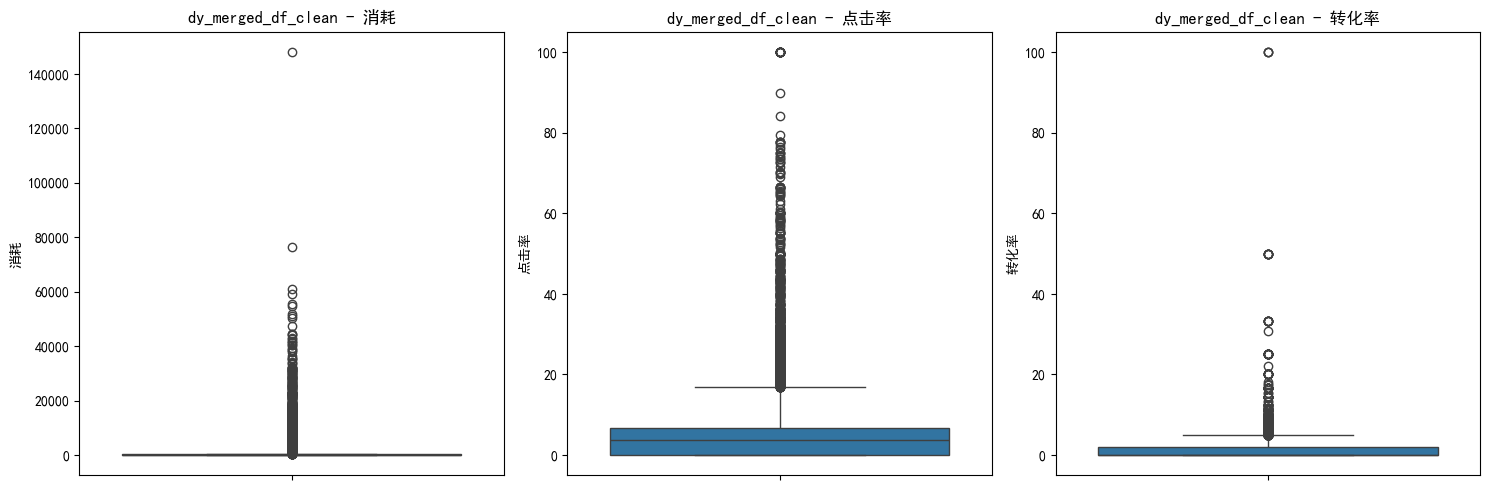

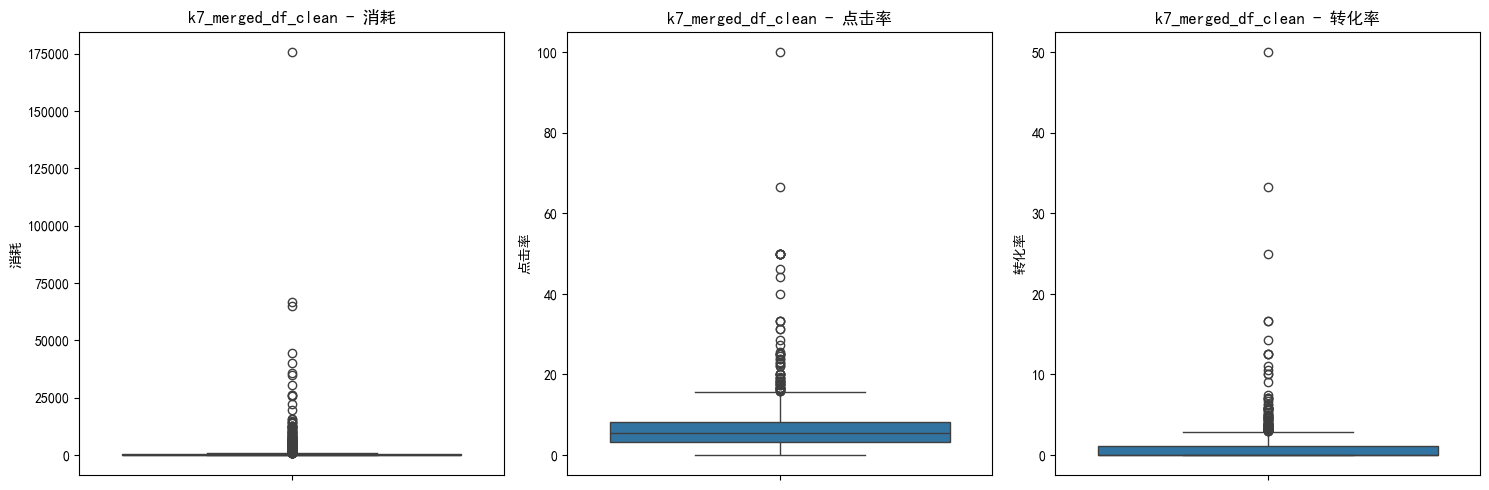

In [ ]:
#查看核心绩效指标分布，作为后续打标规则依据
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 去掉 k7 中列名的“整体”前缀，使列名与 dy 一致
k7_merged_df_clean = k7_merged_df_clean.rename(columns={'整体点击率': '点击率', '整体转化率': '转化率'})

# 绘制 dy_merged_df_clean 的箱线图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
dy_cols = ['消耗', '点击率', '转化率']
for i, col in enumerate(dy_cols):
    sns.boxplot(data=dy_merged_df_clean, y=col, ax=axes[i])
    axes[i].set_title(f'dy_merged_df_clean - {col}')
plt.tight_layout()
plt.show()

# 绘制 k7_merged_df_clean 的箱线图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
k7_cols = ['消耗', '点击率', '转化率']
for i, col in enumerate(k7_cols):
    sns.boxplot(data=k7_merged_df_clean, y=col, ax=axes[i])
    axes[i].set_title(f'k7_merged_df_clean - {col}')
plt.tight_layout()
plt.show()



In [47]:
for name, df, cols in [
    ("dy_merged_df_clean", dy_merged_df_clean, ['消耗', '点击率', '转化率']),
    ("k7_merged_df_clean", k7_merged_df_clean, ['消耗', '点击率', '转化率'])
]:
    print(f"\n{name} 箱线图上边界统计")
    for col in cols:
        if col not in df.columns:
            continue
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        upper_whisker = q3 + 1.5 * iqr
        outlier_count = (df[col] > upper_whisker).sum()
        above_q3_count = (df[col] > q3).sum()
        print(f"{col}: 上四分位={q3:.4f}, 上四分位以上样本数={above_q3_count}, 上边界={upper_whisker:.4f}, 上边界之外样本数={outlier_count}")


dy_merged_df_clean 箱线图上边界统计
消耗: 上四分位=215.8725, 上四分位以上样本数=3135, 上边界=539.6813, 上边界之外样本数=2227
点击率: 上四分位=6.7300, 上四分位以上样本数=3134, 上边界=16.8250, 上边界之外样本数=907
转化率: 上四分位=1.9500, 上四分位以上样本数=3133, 上边界=4.8750, 上边界之外样本数=544

k7_merged_df_clean 箱线图上边界统计
消耗: 上四分位=353.3725, 上四分位以上样本数=330, 上边界=875.1813, 上边界之外样本数=223
点击率: 上四分位=8.2650, 上四分位以上样本数=330, 上边界=15.8175, 上边界之外样本数=62
转化率: 上四分位=1.1700, 上四分位以上样本数=327, 上边界=2.9250, 上边界之外样本数=83


In [48]:
# 计算 dy_merged_df_clean 的 is_popular
# 对于 dy_merged_df_clean，计算 '消耗' 的上边界
q1_dy_consume = dy_merged_df_clean['消耗'].quantile(0.25)
q3_dy_consume = dy_merged_df_clean['消耗'].quantile(0.75)
iqr_dy_consume = q3_dy_consume - q1_dy_consume
upper_whisker_dy_consume = q3_dy_consume + 1.5 * iqr_dy_consume

# '点击率' 和 '转化率' 的上四分位
q3_dy_click = dy_merged_df_clean['点击率'].quantile(0.75)
q3_dy_conv = dy_merged_df_clean['转化率'].quantile(0.75)

# 添加 is_popular 列
dy_merged_df_clean['is_popular'] = (
    (dy_merged_df_clean['消耗'] >= upper_whisker_dy_consume) &
    ((dy_merged_df_clean['点击率'] >= q3_dy_click) | (dy_merged_df_clean['转化率'] >= q3_dy_conv))
).astype(int)

# 计算 k7_merged_df_clean 的 is_popular
# 对于 k7_merged_df_clean，计算 '消耗' 的上边界
q1_k7_consume = k7_merged_df_clean['消耗'].quantile(0.25)
q3_k7_consume = k7_merged_df_clean['消耗'].quantile(0.75)
iqr_k7_consume = q3_k7_consume - q1_k7_consume
upper_whisker_k7_consume = q3_k7_consume + 1.5 * iqr_k7_consume

# '点击率' 和 '转化率' 的上四分位
q3_k7_click = k7_merged_df_clean['点击率'].quantile(0.75)
q3_k7_conv = k7_merged_df_clean['转化率'].quantile(0.75)

# 添加 is_popular 列
k7_merged_df_clean['is_popular'] = (
    (k7_merged_df_clean['消耗'] >= upper_whisker_k7_consume) &
    ((k7_merged_df_clean['点击率'] >= q3_k7_click) | (k7_merged_df_clean['转化率'] >= q3_k7_conv))
).astype(int)

# 计算 is_popular=1 的样本数及其占比
print("dy_merged_df_clean:")
popular_count_dy = dy_merged_df_clean['is_popular'].sum()
total_count_dy = len(dy_merged_df_clean)
proportion_dy = popular_count_dy / total_count_dy * 100
print(f"is_popular=1 的样本数: {popular_count_dy}")
print(f"占比: {proportion_dy:.2f}%")

print("\nk7_merged_df_clean:")
popular_count_k7 = k7_merged_df_clean['is_popular'].sum()
total_count_k7 = len(k7_merged_df_clean)
proportion_k7 = popular_count_k7 / total_count_k7 * 100
print(f"is_popular=1 的样本数: {popular_count_k7}")
print(f"占比: {proportion_k7:.2f}%")

dy_merged_df_clean:
is_popular=1 的样本数: 1752
占比: 13.97%

k7_merged_df_clean:
is_popular=1 的样本数: 143
占比: 10.85%


# 三、联动两组数据，给出最终主表

In [ ]:
#查看两表中现有列名，方便后续对齐
print("dy_merged_df_clean columns:")
print(dy_merged_df_clean.columns.tolist())

print("\nk7_merged_df_clean columns:")
print(k7_merged_df_clean.columns.tolist())

dy_merged_df_clean columns:
['素材ID', '素材创建时间', 'datestamp', '素材名称', '素材标签', '素材时长', '素材类型', '素材来源', '点击率', '转化率', '2秒播放率', '3秒播放率', '5秒播放率', '10秒播放率', '完播率', '消耗', '展示次数', '平均千次展现费用', '点击次数', '转化数', '转化成本', '素材ARPU', '直接成交订单数', '直接成交金额', '直接支付ROI', '直接下单订单数', '直接下单金额', '直接下单ROI', '直接预售订单数', '直接预售金额', '下单智能优惠券金额', '成交智能优惠券金额', '未完结直接预售订单预估金额', '播放数', '有效播放数', '平均单次播放时长', '25%进度播放数', '50%进度播放数', '75%进度播放数', '播放完成数', '新增粉丝数', '直播间观看人次', '直播间超过1分钟观看人次', '直播间新加团人次', '直播间查看购物车次数', '直播间商品点击次数', '直播间评论次数', '直播间分享次数', '直播间打赏次数', '直播间音浪收入', '分享次数', '评论次数', '点赞次数', '不感兴趣数', '举报数', '关联计划数', 'holiday_name', 'isOffDay', 'weekday', '被调休的周末', '休息的周中', 'month', 'shopping_festival', 'is_meaningful_title', 'date_gibberish_title_ratio', 'rollong_5d_giibbersh_ratio', 'family_kw_in_title', 'device_kw_in_title', 'singing_kw_in_title', 'negation_kw_in_title', 'beauty_kw_in_title', 'normalized_title', 'marketing_score', 'attention_score', 'promotion_score', 'is_popular']

k7_merged_df_clean columns:
['素材ID', '

In [ ]:
# 定义四张表的存储路径
output_path_common = os.path.join('../', 'Processed_Data', 'main_perf_merged_common.xlsx')
output_path_all = os.path.join('../', 'Processed_Data', 'main_perf_merged_all.xlsx')
output_path_k7 = os.path.join('../', 'Processed_Data', 'k7_main_perf.xlsx')
output_path_dy = os.path.join('../', 'Processed_Data', 'dy_main_perf.xlsx')

# 对齐含义相同但名称不同的字段
k7_renamed_common = k7_merged_df_clean.rename(columns={
    '整体展现次数': '展示次数',
    '整体点击次数': '点击次数',
    '整体千次展现费用': '平均千次展现费用',
    'normalized_name': 'normalized_title'
})

# 共有字段
common_cols = ['素材ID', '素材名称', '素材时长', '素材创建时间', '素材来源', '展示次数', '点击次数', '消耗', '平均千次展现费用', '点击率', '转化率', 'is_meaningful_title', 'datestamp', 'date_gibberish_title_ratio', 'rollong_5d_giibbersh_ratio', 'family_kw_in_title', 'device_kw_in_title', 'singing_kw_in_title', 'negation_kw_in_title', 'beauty_kw_in_title', 'normalized_title', 'marketing_score', 'attention_score', 'promotion_score', 'is_popular']

# Merge 1: 合并两批素材，仅保留共有指标和is_popular标签，创建source字段标注来源
dy_common = dy_merged_df_clean[common_cols]
k7_common = k7_renamed_common[common_cols]
merged_common = pd.concat([dy_common.assign(source='dy'), k7_common.assign(source='k7')], ignore_index=True)

# Merge 2: 合并两批素材，保留全部指标（非共有指标用空值填充），创建source字段标注来源
merged_all = pd.concat([dy_merged_df_clean.assign(source='dy'), k7_merged_df_clean.assign(source='k7')], ignore_index=True)

# Merge 3: k7直播间素材(近期)全指标
k7_full = k7_merged_df_clean

# Merge 4: dy数据（2023-03-28 到 2025-06-30）全指标
dy_full = dy_merged_df_clean

merged_common.to_excel(output_path_common, index=False)
merged_all.to_excel(output_path_all, index=False)
k7_full.to_excel(output_path_k7, index=False)
dy_full.to_excel(output_path_dy, index=False)

print("Final merged tables have been saved to separate files.")

Final merged tables have been saved to separate files.
